In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

######################## Define the text size of each plot globally ###########
SMALL_SIZE = 10
MEDIUM_SIZE = 10
BIGGER_SIZE = 10

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=SMALL_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title
plt.rcParams["font.family"] = "Arial"
######################## Define the text size of each plot globally ###########

In [2]:
# Creating the dataframe
data = {
    'Parameter': ['E50ref', 'Eoedref', 'Eurref',  'φ\'', 'ψ', 'c’', 'm', 'ѵur', 'Rf', 'K0NC'],
    'Unit': ['kPa', 'kPa', 'kPa', '-', 'kPa', '°', '°', '-', '-', '-'],
    'Target': [60000, 50000, 200000, 33.00, 0.00,  0.00, 0.55, 0.20,  0.90, 0.4553],
    'OA 1': [62440, 57560, 244200, 48.16, 0.00, 0.00, 0.3791, 0.20,  0.90, 0.255],
    'OA 2': [44370, 49340, 198700,  32.97, 0.00,  0.00,0.5614, 0.20, 0.90, 0.4558],
    'OA 3': [61150, 49330, 204100, 32.84,0.00,  0.00, 0.5490,0.20, 0.90, 0.4576],
    'ML': [61188.484, 49350.387, 218044.406, 32.998, 0.001, 0.0, 0.546, 0.206, 0.913, 0.455],
}

input_column_label = ['$E_{50}^{ref}$', '$E_{oed}^{ref}$', '$E_{ur}^{ref}$', 
                      "$\\varphi$'", '$\psi$', "$c'_{ref}$", 
                      '${m}$', '${ν}$', 
                      '${R_f}$', '$K_0^{NC}$']

df = pd.DataFrame(data)
df

,Parameter,Unit,Target,OA 1,OA 2,OA 3,ML
0,E50ref,kPa,60000.0000,62440.0000,44370.0000,61150.0000,61188.484
1,Eoedref,kPa,50000.0000,57560.0000,49340.0000,49330.0000,49350.387
2,Eurref,kPa,200000.0000,244200.0000,198700.0000,204100.0000,218044.406
3,φ',-,33.0000,48.1600,32.9700,32.8400,32.998
4,ψ,kPa,0.0000,0.0000,0.0000,0.0000,0.001
5,c’,°,0.0000,0.0000,0.0000,0.0000,0.000
6,m,°,0.5500,0.3791,0.5614,0.5490,0.546
7,ѵur,-,0.2000,0.2000,0.2000,0.2000,0.206
8,Rf,-,0.9000,0.9000,0.9000,0.9000,0.913
9,K0NC,-,0.4553,0.2550,0.4558,0.4576,0.455


C:\Users\haris\AppData\Local\Temp\ipykernel_18380\2573975261.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs.set_yticklabels(['']*len(input_column_label), rotation=0)


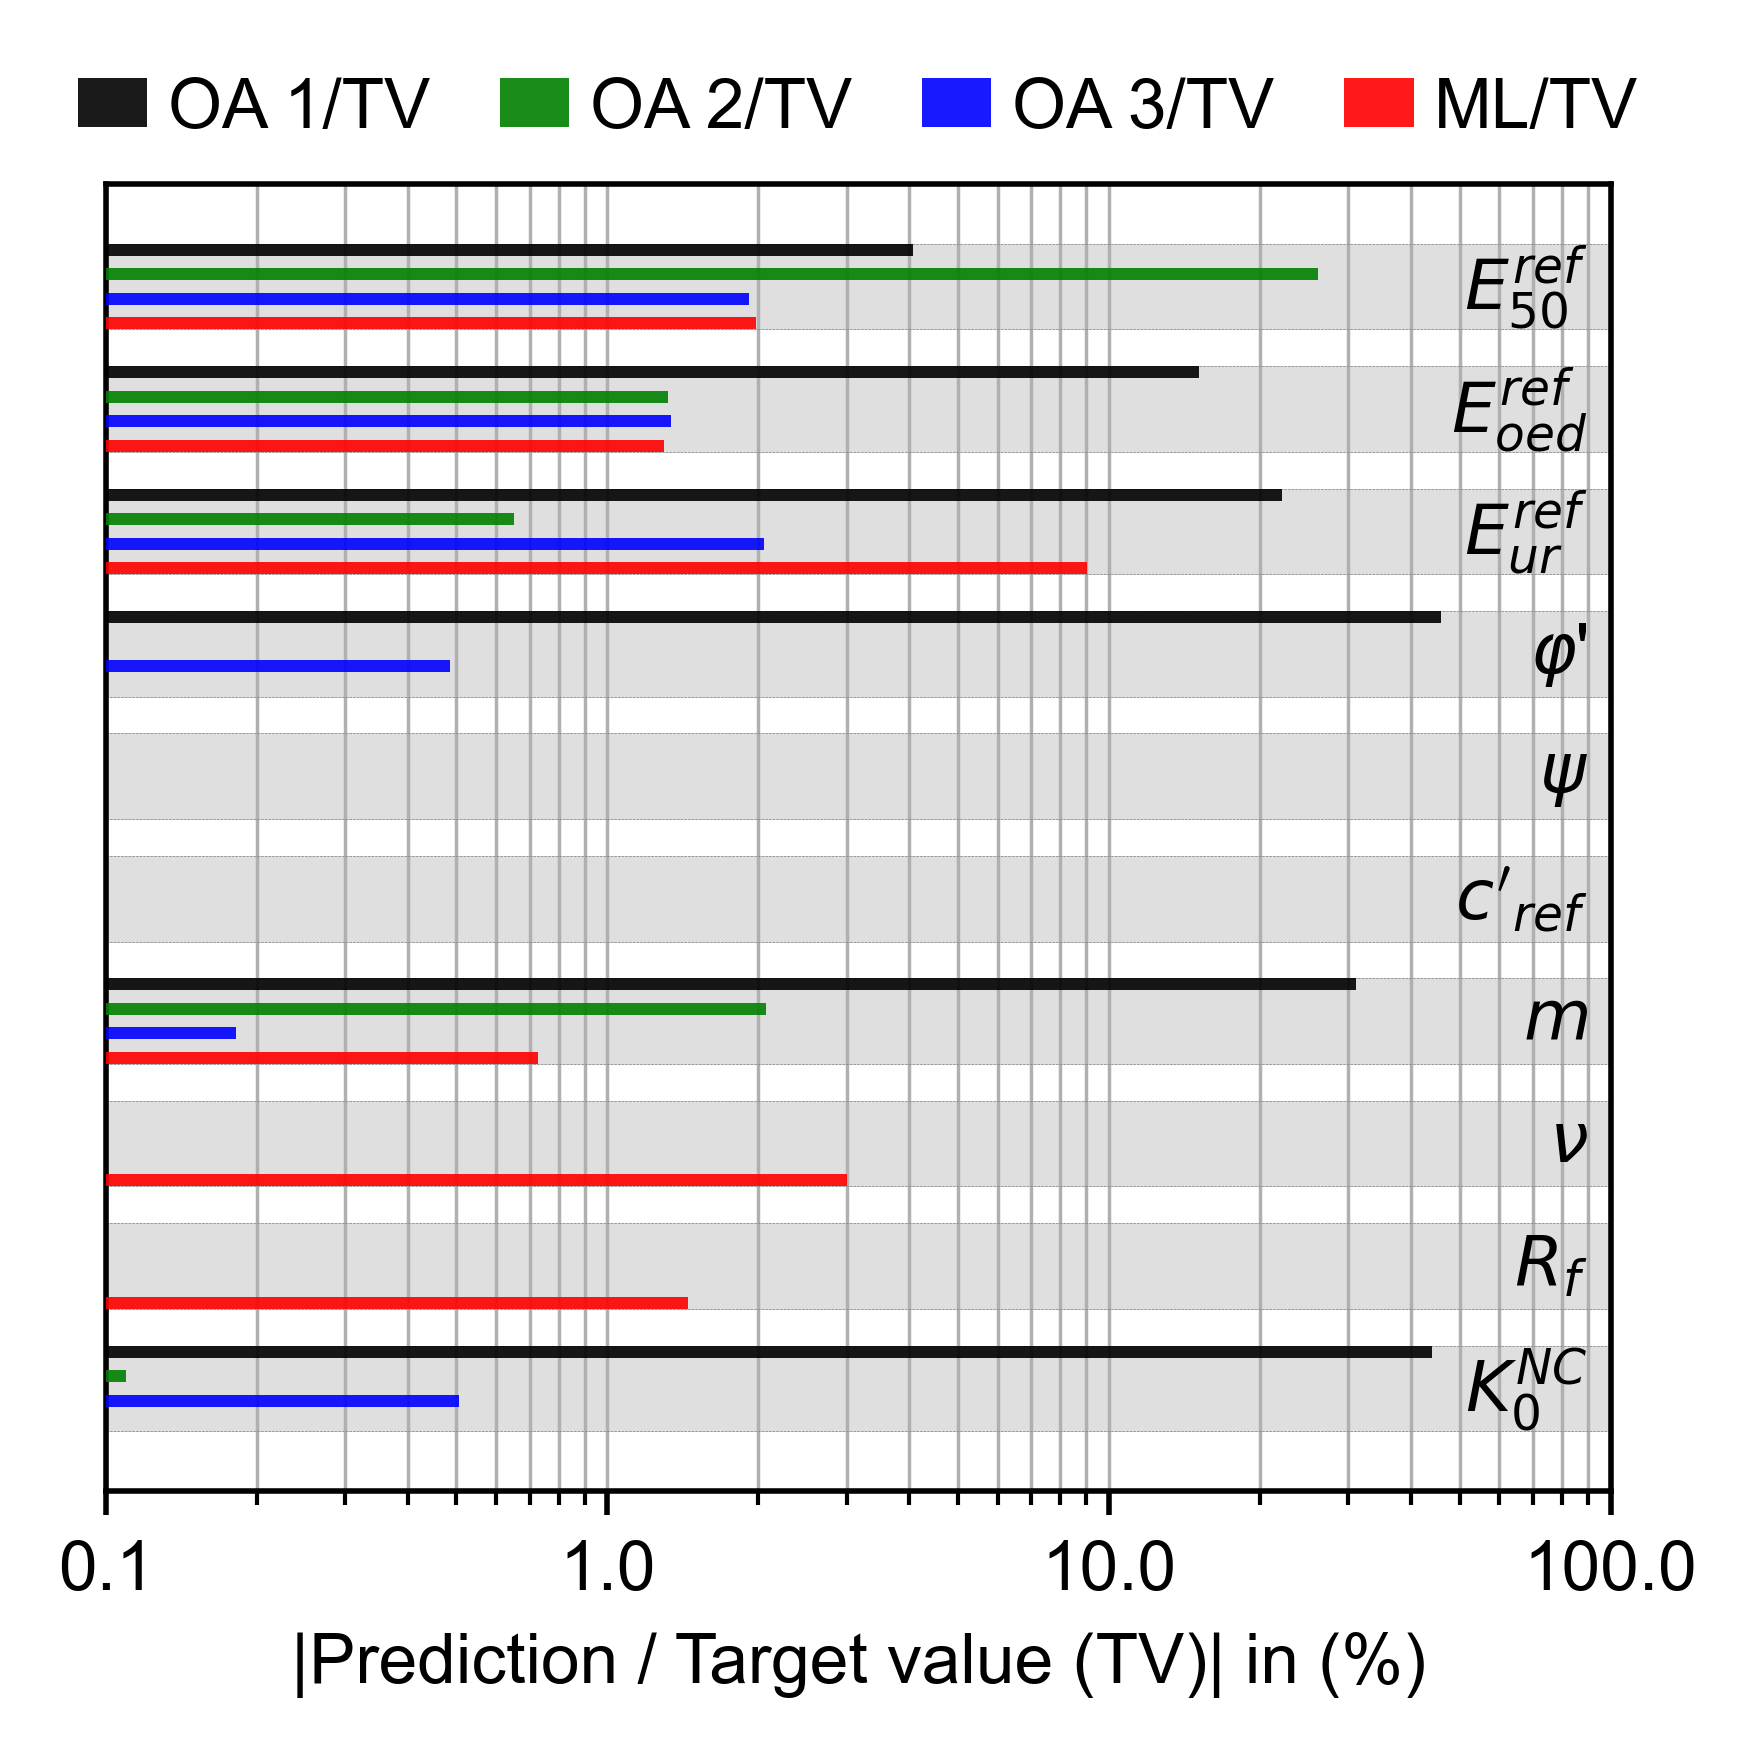

In [3]:
cm = 1 / 2.54  # centimeters in inches
fig, axs = plt.subplots(1, 1, figsize=(8.4 * cm, 8.4 * cm), dpi=500, sharey=True)  # Changed to 1 row, 1 column

bar_width = 0.1
index = range(len(df))

colors = ['k', 'g', 'b', 'r', 'g']

for i in range(4):
    bar_positions = [x + 2 * i * bar_width for x in index]
    values = abs((df.iloc[:, 3 + i] / df['Target']) * 100 - 100)
    bars = axs.barh(bar_positions, values, bar_width, label=f'{df.columns[3 + i]}/TV', alpha=0.9, lw = 0,edgecolor='black', color=colors[i], zorder=10)

for i, label in enumerate(input_column_label):
    axs.text(x=90, y=index[i] + bar_width * 3, s=label, ha='right', va='center', rotation=0)

axs.tick_params(axis='y', length=0)
axs.set_yticklabels(['']*len(input_column_label), rotation=0) 


for idx, param in enumerate(input_column_label):
    lower_line = idx - bar_width / 2
    upper_line = idx + bar_width * 6.5
    axs.axhline(y=lower_line, color='gray', lw=0.1, linestyle='--')
    axs.axhline(y=upper_line, color='gray', lw=0.1, linestyle='--')
    axs.fill_betweenx([lower_line, upper_line], 0.1, 100, facecolor='gray', alpha=0.25 , linewidth=0.1, edgecolor='gray')

axs.set_xlim(xmin=0.1, xmax=100)
axs.grid(True, axis='x', which='both', linewidth=0.5, zorder=-10)
axs.grid(False, axis='y')  # Disable horizontal grid lines

axs.invert_yaxis()
axs.set_xscale('log')
axs.set_xticks([0.1, 1, 10, 100])
axs.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}'))
axs.legend(loc='upper center', bbox_to_anchor=(0.50, 1.13), frameon=False, ncol=4, handlelength=1, handletextpad=0.3, columnspacing=1)
axs.set_xlabel('|Prediction / Target value (TV)| in (%)')


plt.subplots_adjust(left=0.04, right=0.95, bottom=0.13, top=0.92, wspace=0.40, hspace=0.2)
example = '102_SyntheticExample_Final_Difference'
plt.savefig(r"../graphics/" + "Synthetic_" + f"{example}" + ".png", dpi=1000)